In [17]:
!python --version

Python 3.11.9


In [18]:
%matplotlib inline

# Setup Auth

In [19]:
import os

def define_auth():
    os.environ["HF_TOKEN"] = ""

# Setup Dataset

In [20]:
import pandas as pd

def get_dataset(type="train"):
    splits = {'train': 'train_meta.csv', 'test': 'test_meta.csv'}
    df = pd.read_csv("hf://datasets/lasfk/EEG-fNIRS-based-Handwriting-Trajectory-Dataset/" + splits[type])
    return df

# Data Training

In [21]:
define_auth()
df_train = get_dataset(type="train")
print(df_train.head())

C:\Users\aldha\PycharmProjects\PythonProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


      trial_id subject  session  onset_sec  event_code  label
0  sub_01_1_00  sub_01        1     25.060         203      3
1  sub_01_1_01  sub_01        1     49.410         201      1
2  sub_01_1_02  sub_01        1     73.870         201      1
3  sub_01_1_03  sub_01        1     98.695         201      1
4  sub_01_1_04  sub_01        1    123.850         202      2


Dari contoh dataset training di atas, berikut isi dari tiap kolomnya:
- trial_id: unique trial identifier
- subject: subject_id/participant/responden eksperimen
- session: session_id/1 sesi rekaman penuh
- onset_sec: waktu mulai (onset) suatu trial dalam satuan detik, dihiting relatif terhadap awal rekaman EEG
- event_code: kode event asli yang ada di data sumber (sebelum diproses atau dimapping ulang)

Gabungan subject + session = lokasi raw data

# Raw Training Data (EEG)

In [22]:
import mne

def read_bdf(subject, session):
    path = f"datasets/raw/{subject}/EEG/{session}.bdf"
    raw = mne.io.read_raw_bdf(path, preload=True)
    return raw

def plot_bdf(raw_bdf):
    print(raw_bdf.info)
    raw_bdf.plot(scalings=dict(eeg=100e-6))

## Plot graf BDF (subject="sub_01", session=1)

### Plot Graph

Untuk melihat data, kita coba ambil sampel untuk subject `sub_01` dan session `1` 

Read `.bdf` file dengan subject = "sub_01", dan session = 1

In [23]:
sub_01_session_1_bdf = read_bdf(subject="sub_01", session=1)

Extracting BDF parameters from datasets/raw/sub_01/EEG/1.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 954999  =      0.000 ...   954.999 secs...


<Info | 8 non-empty values
 bads: []
 ch_names: Fpz, Fp1, Fp2, AF3, AF4, AF7, AF8, Fz, F1, F2, F3, F4, F5, F6, ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 1000.0 Hz
 meas_date: 2025-08-28 15:31:54 UTC
 nchan: 64
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: x, sex: 2, last_name: zhaosiwei, birthday: 1970-01-01>
>
Using matplotlib as 2D backend.


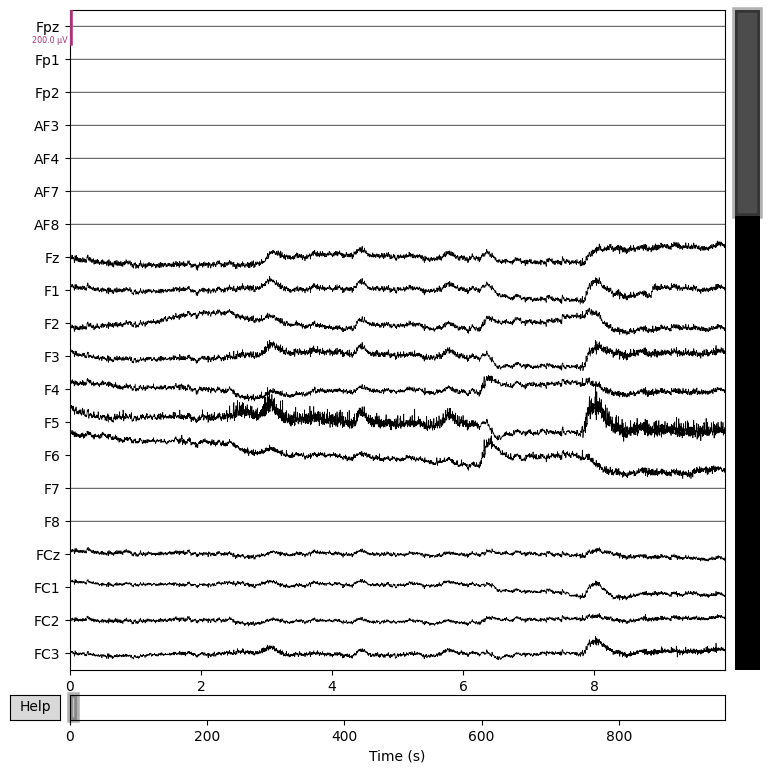

In [24]:
plot_bdf(sub_01_session_1_bdf)

### Validasi Channel 

Di validasi channel ini, kita akan melihat channel mana yang mati, dan hidup.

In [25]:
sub_01_session_1_data = sub_01_session_1_bdf.get_data()

import numpy as np

variances = np.var(sub_01_session_1_data, axis=1)
for ch, var in zip(sub_01_session_1_bdf.ch_names, variances):
    print(ch, var)

Fpz 0.0
Fp1 0.0
Fp2 0.0
AF3 0.0
AF4 0.0
AF7 0.0
AF8 0.0
Fz 2.953587446728076e-07
F1 1.4089012899268369e-06
F2 7.506483138148929e-08
F3 7.492099786134827e-07
F4 4.7611453705614255e-07
F5 2.4366713795700535e-06
F6 2.1719860590234637e-06
F7 0.0
F8 0.0
FCz 1.3335779273942218e-07
FC1 1.019800065846137e-06
FC2 8.40284170035173e-08
FC3 3.1594477114720284e-07
FC4 6.54173559953871e-07
FC5 2.567210487094837e-06
FC6 4.989660297522416e-06
FT7 0.0
FT8 0.0
Cz 2.8131197567284605e-08
C1 1.875542818786127e-06
C2 5.872203013061993e-07
C3 1.9755099849171124e-06
C4 2.1767164812465635e-06
C5 1.69622299711515e-07
C6 1.755001421217545e-06
T7 0.0
T8 0.0
CP1 7.934931796084146e-07
CP2 1.2886738557268864e-06
CP3 1.0957135863532347e-07
CP4 1.3330012155424586e-06
CP5 1.05753349748366e-06
CP6 2.3950288804225586e-06
TP7 0.0
TP8 0.0
Pz 0.0
P3 0.0
P4 0.0
P5 0.0
P6 0.0
P7 0.0
P8 0.0
POz 0.0
PO3 0.0
PO4 0.0
PO5 0.0
PO6 0.0
PO7 0.0
PO8 0.0
Oz 0.0
O1 0.0
O2 0.0
ECG 0.0
HEOR 0.0
HEOL 0.0
VEOU 0.0
VEOL 0.0


Dari list di atas, kita dapat melihat, bahwa channel yang hidup adalah: 
- Frontal (Fz, F1, F2, F3, F4, F5, F6)
- Fronto-central (FCz, FC1, FC2, FC3, FC4, FC5, FC6)
- Central (Cz, C1, C2, C3, C4, C5, C6)
- Centro-parietal (CP1, CP2, CP3, CP4, CP5, CP6)

### Frequency Analysis

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


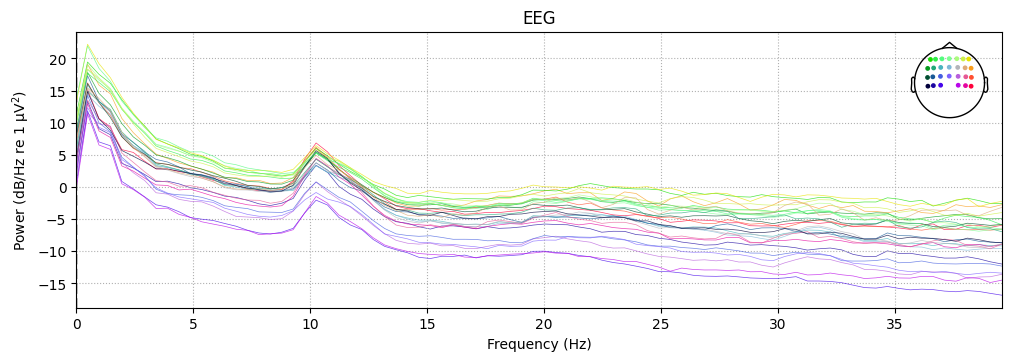

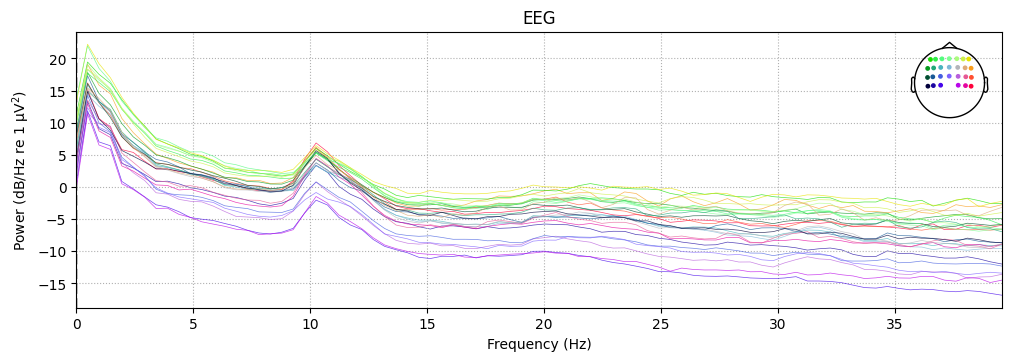

In [26]:
sub_01_session_1_bdf_data = sub_01_session_1_bdf.get_data()

non_empty_channels = [
    ch for ch, d in zip(sub_01_session_1_bdf.ch_names, sub_01_session_1_bdf_data)
    if np.std(d) > 1e-6
]

sub_01_session_1_bdf_clean = sub_01_session_1_bdf.copy().pick(non_empty_channels)
sub_01_session_1_bdf_clean.set_montage("standard_1020")
sub_01_session_1_bdf_clean.compute_psd(fmax=40).plot(show=False)



### Slice per trial

In [27]:
import numpy as np

def slice_trial(raw, onset_sec, window_sec=3.0):
    sfreq = raw.info['sfreq']
    data = raw.get_data()

    start = int(onset_sec * sfreq)
    end = start + int(window_sec * sfreq)

    # handle out of bound
    if end > data.shape[1]:
        return None

    return data[:, start:end] 

In [28]:
def build_trials(raw, df, window_sec=3.0):
    X = []
    y = []

    for _, row in df.iterrows():
        onset = row['onset_sec']
        label = row.get('label', None)  

        trial = slice_trial(raw, onset, window_sec)

        if trial is None:
            continue

        X.append(trial)
        if label is not None:
            y.append(label)

    X = np.array(X)
    y = np.array(y) if y else None

    return X, y

In [29]:
df_train_sample = df_train[(df_train['subject'] == 'sub_01') & (df_train['session'] == 1)]

sub_01_session_1_data = sub_01_session_1_bdf.get_data()
non_empty_ch = [ch for ch, d in zip(sub_01_session_1_bdf.ch_names, sub_01_session_1_data) if np.std(d) > 1e-6]
raw_clean_sample = sub_01_session_1_bdf.copy().pick(non_empty_ch)

X, y = build_trials(raw_clean_sample, df_train_sample, window_sec=3.0)
print(X.shape)
print(y.shape)

(36, 27, 3000)
(36,)


Dari output di atas
36 Jumlah trial
27 Jumlah channel
3000 time steps


X = (num_trials, channels, time)
y = (num_trials,)
format yang ideal untuk masuk model

### Compare antar label

Feature shape: (36, 108)
PCA shape: (36, 2)


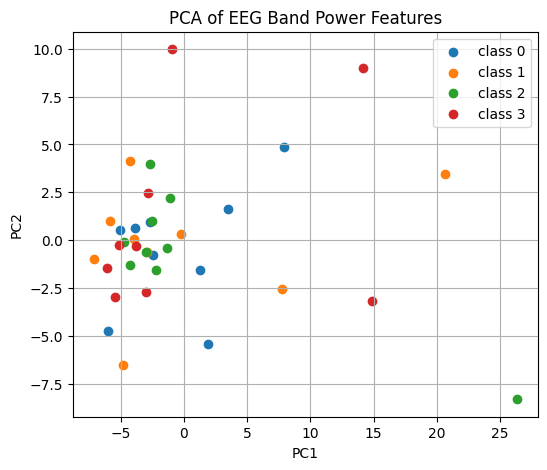

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Ambil rata-rata power di frekuensi tertentu
def band_power(signal, sfreq, fmin, fmax):
    f, Pxx = welch(signal, fs=sfreq, nperseg=1024)
    idx = (f >= fmin) & (f <= fmax)
    return np.mean(Pxx[idx])


# define frekuensi beserta min - max nya
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30)
}


# extract feature, dengan power delta,theta,alpha,beta sebagai fitur nya
features = []
labels = []

for trial, label in zip(X, y):
    trial_feat = []

    for ch_signal in trial:
        for band_name, (fmin, fmax) in bands.items():
            bp = band_power(ch_signal, sfreq, fmin, fmax)
            trial_feat.append(bp)

    features.append(trial_feat)
    labels.append(label)

features = np.array(features)
labels = np.array(labels)

print("Feature shape:", features.shape)  



# normalisasi fitur
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


# visualisasi dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features_scaled)

print("PCA shape:", X_pca.shape)


# Plot PCA
plt.figure(figsize=(6,5))

for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"class {label}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of EEG Band Power Features")
plt.legend()
plt.grid()
plt.show()

# Raw Training Data (fNIRS)

In [31]:
import pandas as pd

def read_fnirs(subject, session):
    path = f"datasets/raw/{subject}/fNIRS/{session}.csv"
    fnirs = pd.read_csv(path)
    return fnirs

## Plot graf fNIRS (subject="sub_01", session=1)

### Load & Check Struktur Data

In [32]:
fnirs_train = read_fnirs(subject="sub_01", session=1)
print(fnirs_train.head())
print(fnirs_train.columns)
print(len(fnirs_train))

       Time   fnirs_1   fnirs_2   fnirs_3   fnirs_4   fnirs_5   fnirs_6  \
0  0.000000  1.021882  1.339357  0.547761  0.757111  9.135751  9.202432   
1  0.015625  1.024323  1.341340  0.550568  0.760163  9.142770  9.210855   
2  0.031250  1.027009  1.344453  0.552796  0.762818  9.150460  9.222360   
3  0.046875  1.023133  1.340303  0.549286  0.758424  9.138681  9.206247   
4  0.062500  1.025758  1.342744  0.551880  0.761140  9.147103  9.216653   

    fnirs_7   fnirs_8  
0  9.638742  8.732857  
1  9.649484  8.746316  
2  9.660074  8.761758  
3  9.643991  8.738991  
4  9.654825  8.754037  
Index(['Time', 'fnirs_1', 'fnirs_2', 'fnirs_3', 'fnirs_4', 'fnirs_5',
       'fnirs_6', 'fnirs_7', 'fnirs_8'],
      dtype='str')
66684


### Plot 1 channel (channel 1)

In [33]:
fnirs_cols = [c for c in fnirs_train.columns if "fnirs" in c]

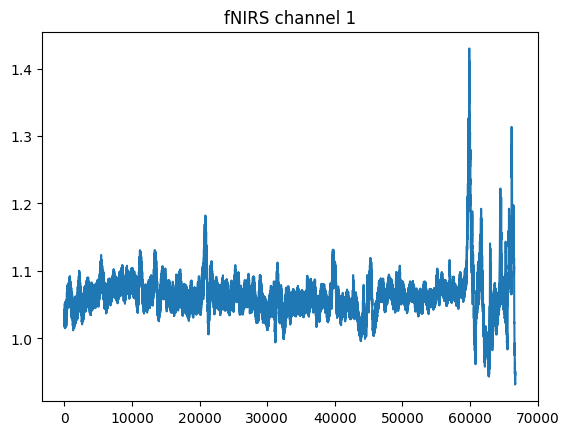

In [34]:
import matplotlib.pyplot as plt

plt.plot(fnirs_train[fnirs_cols[0]])
plt.title("fNIRS channel 1")
plt.show()

### Hitung sampling rate

In [35]:
time_diff_mean = fnirs_train["Time"].diff().mean()
print(f"rata-rata selisih waktu antar sample: {time_diff_mean}")
sfreq = 1 / time_diff_mean
print(f"sample frequency: {sfreq}")

rata-rata selisih waktu antar sample: 0.015625
sample frequency: 64.0


### Slice per trial

In [36]:
def slice_fnirs_trial(fnirs, onset_sec, window_sec, sfreq, fnirs_cols):
    data = fnirs[fnirs_cols].values

    start = int(onset_sec * sfreq)
    end = start + int(window_sec * sfreq)

    # handle out of bounds
    if end > data.shape[0]:
        return None

    return data[start:end]

In [37]:
def build_fnirs_trials(fnirs, df_meta, window_sec=5.0):
    X_fnirs = []
    y_fnirs = []

    for _, row in df_meta.iterrows():
        onset = row["onset_sec"]
        label = row.get("label", None)

        trial = slice_fnirs_trial(fnirs, onset, window_sec, sfreq, fnirs_cols)

        if trial is None:
            continue

        X_fnirs.append(trial)

        if label is not None:
            y_fnirs.append(label)

    X_fnirs = np.array(X_fnirs)
    y_fnirs = np.array(y_fnirs) if y_fnirs else None

    return X_fnirs, y_fnirs

In [38]:
# filter metadata (sub_01, session 1)
df_train_sample = df_train[(df_train['subject'] == 'sub_01') & (df_train['session'] == 1)]

X_fnirs, y_fnirs = build_fnirs_trials(fnirs_train, df_train_sample, window_sec=5.0)

print("X_fnirs shape:", X_fnirs.shape)
print("y_fnirs shape:", y_fnirs.shape)

X_fnirs shape: (36, 320, 8)
y_fnirs shape: (36,)


X_fnirs = (trial, time, channel)

### Compare antar label

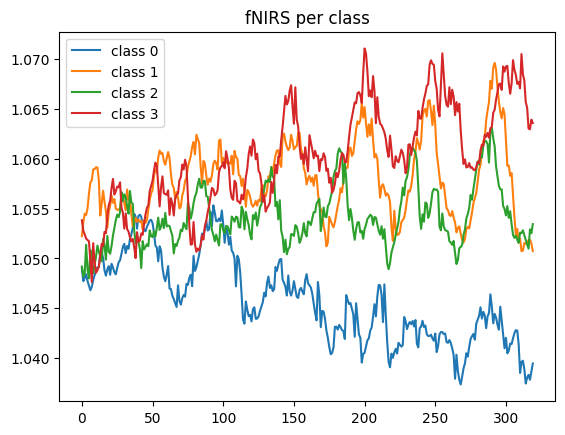

In [39]:
import numpy as np

for label in range(4):
    mean_signal = X_fnirs[y_fnirs == label].mean(axis=0)
    plt.plot(mean_signal[:, 0], label=f"class {label}")

plt.legend()
plt.title("fNIRS per class")
plt.show()